In [3]:
import os
os.path.exists('/content/drive/MyDrive')

False

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

df = pd.read_parquet("/content/drive/MyDrive/amazon_reviews_clean.parquet")
print(df.shape)
df['sentiment'].value_counts()

(74545, 9)


,count
sentiment,
positive,58302
negative,9581
neutral,6662


In [6]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train size: (59636,)
Test size: (14909,)
sentiment
positive    0.782111
negative    0.128530
neutral     0.089359
Name: proportion, dtype: float64
sentiment
positive    0.782078
negative    0.128513
neutral     0.089409
Name: proportion, dtype: float64


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words='english',
    lowercase=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)

Train TF-IDF shape: (59636, 20000)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_tfidf, y_train)
print("Training complete")

Training complete


              precision    recall  f1-score   support

    negative       0.55      0.70      0.61      1916
     neutral       0.26      0.48      0.34      1333
    positive       0.95      0.81      0.88     11660

    accuracy                           0.77     14909
   macro avg       0.59      0.66      0.61     14909
weighted avg       0.84      0.77      0.80     14909

Macro F1: 0.6095044472891874


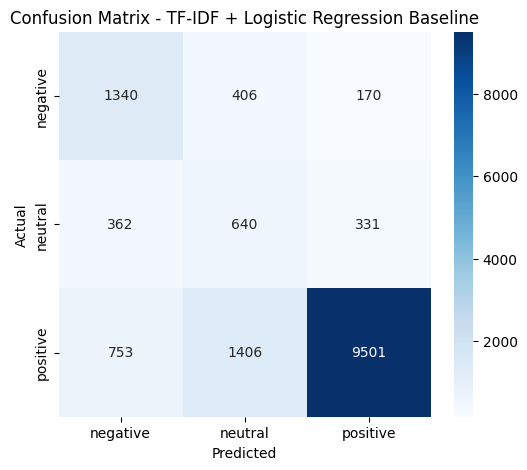

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))

cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TF-IDF + Logistic Regression Baseline')
plt.show()

In [10]:
import json

baseline_results = {
    "model": "TF-IDF + Logistic Regression",
    "macro_f1": 0.6095,
    "accuracy": 0.77,
    "negative_f1": 0.61,
    "neutral_f1": 0.34,
    "positive_f1": 0.88
}

with open("baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print("Saved baseline results")

Saved baseline results


In [11]:
import shutil
shutil.copy("baseline_results.json", "/content/drive/MyDrive/baseline_results.json")

'/content/drive/MyDrive/baseline_results.json'

In [1]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU available: True
Device name: Tesla T4


In [2]:
!pip install -q transformers datasets accelerate scikit-learn

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_parquet("/content/drive/MyDrive/amazon_reviews_clean.parquet")
print(df.shape)
df['sentiment'].value_counts()

Mounted at /content/drive
(74545, 9)


,count
sentiment,
positive,58302
negative,9581
neutral,6662


In [5]:
from sklearn.model_selection import train_test_split

# Small test sample - stratified
df_sample = df.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1000), random_state=42)
)
print(df_sample['sentiment'].value_counts())

label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_sample['label'] = df_sample['sentiment'].map(label_map)

train_df, test_df = train_test_split(
    df_sample, test_size=0.2, stratify=df_sample['sentiment'], random_state=42
)
print("Train:", train_df.shape, "Test:", test_df.shape)

sentiment
negative    1000
neutral     1000
positive    1000
Name: count, dtype: int64
Train: (2400, 10) Test: (600, 10)


/tmp/ipykernel_449/1833984073.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('sentiment', group_keys=False).apply(


In [6]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_function(texts):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors='pt'
    )

train_encodings = tokenize_function(train_df['clean_text'].tolist())
test_encodings = tokenize_function(test_df['clean_text'].tolist())

print("Train input_ids shape:", train_encodings['input_ids'].shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train input_ids shape: torch.Size([2400, 256])


In [7]:
import torch

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_df['label'].tolist())
test_dataset = ReviewDataset(test_encodings, test_df['label'].tolist())

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 2400
Test dataset size: 600


In [8]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

print("Model loaded")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [9]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'macro_f1': f1_score(labels, predictions, average='macro')
    }

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_dir='./logs',
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer set up")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer set up


In [10]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.694561,0.645376,0.705000,0.702861
2,0.389807,0.698772,0.698333,0.693570


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=300, training_loss=0.6266119496027629, metrics={'train_runtime': 117.3161, 'train_samples_per_second': 40.915, 'train_steps_per_second': 2.557, 'total_flos': 317927426457600.0, 'train_loss': 0.6266119496027629, 'epoch': 2.0})

In [11]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

from sklearn.model_selection import train_test_split

train_df_full, test_df_full = train_test_split(
    df, test_size=0.2, stratify=df['sentiment'], random_state=42
)

print("Train:", train_df_full.shape)
print("Test:", test_df_full.shape)
print(train_df_full['sentiment'].value_counts(normalize=True))

Train: (59636, 10)
Test: (14909, 10)
sentiment
positive    0.782111
negative    0.128530
neutral     0.089359
Name: proportion, dtype: float64


In [12]:
train_encodings_full = tokenize_function(train_df_full['clean_text'].tolist())
test_encodings_full = tokenize_function(test_df_full['clean_text'].tolist())

train_dataset_full = ReviewDataset(train_encodings_full, train_df_full['label'].tolist())
test_dataset_full = ReviewDataset(test_encodings_full, test_df_full['label'].tolist())

print("Full train dataset size:", len(train_dataset_full))
print("Full test dataset size:", len(test_dataset_full))

Full train dataset size: 59636
Full test dataset size: 14909


In [13]:
model_full = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)
print("Fresh model loaded for full training")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model loaded for full training


In [14]:
from transformers import TrainingArguments, Trainer

training_args_full = TrainingArguments(
    output_dir='./results_full',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_dir='./logs_full',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    fp16=True,
)

trainer_full = Trainer(
    model=model_full,
    args=training_args_full,
    train_dataset=train_dataset_full,
    eval_dataset=test_dataset_full,
    compute_metrics=compute_metrics,
)

print("Full trainer set up")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Full trainer set up


In [15]:
trainer_full.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.312469,0.322109,0.875646,0.681303
2,0.199778,0.312077,0.886780,0.724348


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3728, training_loss=0.2869294545425366, metrics={'train_runtime': 750.6448, 'train_samples_per_second': 158.893, 'train_steps_per_second': 4.966, 'total_flos': 7899966668427264.0, 'train_loss': 0.2869294545425366, 'epoch': 2.0})

              precision    recall  f1-score   support

    negative       0.76      0.76      0.76      1916
     neutral       0.49      0.43      0.46      1333
    positive       0.95      0.96      0.95     11660

    accuracy                           0.89     14909
   macro avg       0.73      0.72      0.72     14909
weighted avg       0.88      0.89      0.88     14909



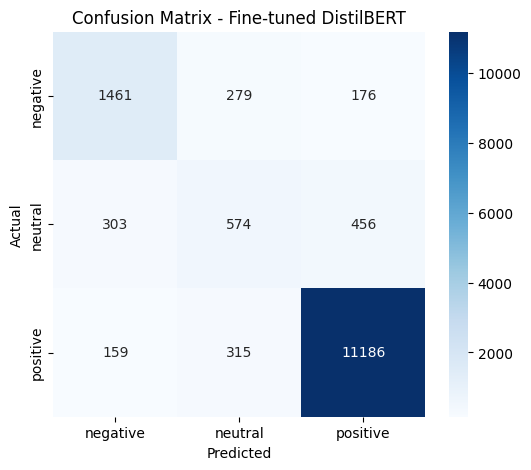

In [16]:
predictions = trainer_full.predict(test_dataset_full)
y_pred_bert = predictions.predictions.argmax(axis=-1)
y_true_bert = predictions.label_ids

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

label_names = ['negative', 'neutral', 'positive']
print(classification_report(y_true_bert, y_pred_bert, target_names=label_names))

cm = confusion_matrix(y_true_bert, y_pred_bert)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Fine-tuned DistilBERT')
plt.show()

In [17]:
model_full.save_pretrained("distilbert_sentiment_model")
tokenizer.save_pretrained("distilbert_sentiment_model")

import shutil
shutil.make_archive("distilbert_sentiment_model", 'zip', "distilbert_sentiment_model")
print("Model saved and zipped")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved and zipped


In [13]:
# Categories table
categories_df = pd.DataFrame({'category_name': df['category'].unique()})
categories_df

# Products table - one row per unique ASIN
products_df = df[['asin', 'category', 'title']].drop_duplicates(subset='asin').rename(
    columns={'asin': 'product_id', 'title': 'product_title'}
)
print(products_df.shape)

# Reviews table
reviews_df = df[['asin', 'rating', 'clean_text', 'sentiment', 'helpful_vote', 'verified_purchase', 'timestamp']].rename(
    columns={'asin': 'product_id', 'clean_text': 'review_text', 'timestamp': 'review_timestamp'}
)
print(reviews_df.shape)

(57785, 3)
(74545, 7)


In [ ]:
!pip install -q psycopg2-binary sqlalchemy

from getpass import getpass
from sqlalchemy import create_engine

DATABASE_URL = getpass("Enter your Supabase connection string: ")
engine = create_engine(DATABASE_URL)
categories_df.to_sql('categories', engine, if_exists='append', index=False)
print("Categories loaded")


In [28]:
import pandas as pd

category_mapping = pd.read_sql("SELECT category_id, category_name FROM categories", engine)
print(category_mapping)

   category_id             category_name
0            1               Electronics
1            2  Beauty_and_Personal_Care
2            3          Home_and_Kitchen
3            4                  Software


In [27]:
# Merge into products_df
products_df = products_df.merge(
    category_mapping, left_on='category', right_on='category_name', how='left'
)
products_df = products_df[['product_id', 'category_id', 'product_title']]
print(products_df.head())
print(products_df.shape)

   product_id  category_id                                product_title
0  B083NRGZMM            1            Smells like gasoline! Going back!
1  B07N69T6TM            1      Didn’t work at all lenses loose/broken.
2  B01G8JO5F2            1                                   Excellent!
3  B001OC5JKY            1                       Great laptop backpack!
4  B013J7WUGC            1  Best Headphones in the Fifties price range!
(57785, 3)


In [28]:
products_df.to_sql('products', engine, if_exists='append', index=False, chunksize=5000, method='multi')
print("Products loaded")

Products loaded


In [29]:
reviews_df.to_sql('reviews', engine, if_exists='append', index=False, chunksize=5000, method='multi')
print("Reviews loaded")

Reviews loaded


In [30]:
result = pd.read_sql("SELECT COUNT(*) FROM reviews", engine)
print(result)

   count
0  74545


In [15]:
category_mapping = pd.read_sql("SELECT category_id, category_name FROM categories", engine)
print(category_mapping)

   category_id             category_name
0            1               Electronics
1            2  Beauty_and_Personal_Care
2            3          Home_and_Kitchen
3            4                  Software


In [16]:
products_df = products_df.merge(
    category_mapping, left_on='category', right_on='category_name', how='left'
)
products_df = products_df[['product_id', 'category_id', 'product_title']]
print(products_df.head())
print(products_df.shape)

   product_id  category_id                                product_title
0  B083NRGZMM            1            Smells like gasoline! Going back!
1  B07N69T6TM            1      Didn’t work at all lenses loose/broken.
2  B01G8JO5F2            1                                   Excellent!
3  B001OC5JKY            1                       Great laptop backpack!
4  B013J7WUGC            1  Best Headphones in the Fifties price range!
(57785, 3)


In [17]:
existing_products = pd.read_sql("SELECT COUNT(*) FROM products", engine)
print(existing_products)

   count
0  57785


In [19]:
products_df = products_df.rename(columns={'product_title': 'sample_review_title'})
print(products_df.columns)

Index(['product_id', 'category_id', 'sample_review_title'], dtype='object')


In [21]:
existing_products = pd.read_sql("SELECT COUNT(*) FROM products", engine)
print(existing_products)

   count
0  57785


In [22]:
existing_reviews = pd.read_sql("SELECT COUNT(*) FROM reviews", engine)
print(existing_reviews)

   count
0  74545
